# Settings and Utilities

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 16,           # base font size
    'axes.titlesize': 18,      # title
    'axes.labelsize': 16,      # x, y axis labels
    'xtick.labelsize': 14,     # x-axis ticks
    'ytick.labelsize': 14,     # y-axis ticks
    'legend.fontsize': 14,     # legend
    'figure.titlesize': 18
})

from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# ============================================================
# Dataset root folder.
# Change this single line if the Drive folder is renamed or moved;
# every dataset path in this notebook is derived from it.
# ============================================================
DATA_ROOT = Path('/content/drive/MyDrive/PHM Practice/Datasets')
PROJECT_ROOT = DATA_ROOT.parent   # for outputs saved outside Datasets/


Mounted at /content/drive


## Shared utility functions

In [ ]:
import copy
import numpy as np
import pandas as pd
import h5py
import scipy.io as sio
import torch
import torch.nn as nn
import torch.optim as optim

from IPython.display import display
from matplotlib.patches import Ellipse
from scipy.io import loadmat, savemat
from scipy.stats import norm, multivariate_normal, skew, kurtosis
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# The functions below are used across multiple sections of this notebook.
# Run this cell once; every later section can then be run independently.

# ============================================================
# Time-domain feature extraction (11 features per signal)
# Input : x  - raw vibration signal (1-D array)
# Output: 1-D array of 11 features:
#         [mean, std, rms, skewness, kurtosis, shape_factor,
#          crest_factor, impulse_factor, margin_factor, peak, peak-to-peak]
# ============================================================
def time_features(x):
    x           = np.asarray(x, dtype=float).ravel()
    n           = x.size
    x_mean      = np.sum(x) / n
    x_std       = np.std(x, ddof=1)
    x_rms       = np.sqrt(np.sum(x ** 2) / n)
    x_skew      = skew(x)
    x_kurt      = kurtosis(x, fisher=False)
    mean_abs      = np.sum(np.abs(x)) / n
    mean_sqrt_abs = np.sum(np.sqrt(np.abs(x))) / n
    x_peak      = np.max(np.abs(x))
    x_shape     = x_rms / mean_abs
    x_crest     = x_peak / x_rms
    x_impulse   = x_peak / mean_abs
    x_margin    = x_peak / mean_sqrt_abs ** 2
    x_p2p       = np.max(x) - np.min(x)
    return np.array([x_mean, x_std, x_rms, x_skew, x_kurt,
                     x_shape, x_crest, x_impulse, x_margin, x_peak, x_p2p], dtype=float)


# ============================================================
# J3 criterion for feature subset evaluation
# Input : data  - (n_samples, n_features) feature array
#         label - (n_samples,) integer class labels
# Output: scalar J3 = trace(Sw^{-1} @ (Sw + Sb))
# ============================================================
def j3_score(data, label):
    data  = np.asarray(data, dtype=float)
    label = np.asarray(label)
    if data.ndim == 1:
        data = data[:, None]
    classes = np.unique(label)
    n_sample, n_feature = data.shape
    global_mean = np.mean(data, axis=0, keepdims=True)
    sw = np.zeros((n_feature, n_feature), dtype=float)
    sb = np.zeros((n_feature, n_feature), dtype=float)
    for class_id in classes:
        class_data = data[label == class_id]
        class_mean = np.mean(class_data, axis=0, keepdims=True)
        centered   = class_data - class_mean
        sw += (len(class_data) / n_sample) * (centered.T @ centered / (len(class_data) - 1))
        mean_diff = (class_mean - global_mean).T
        sb += (len(class_data) / n_sample) * (mean_diff @ mean_diff.T)
    return float(np.trace(np.linalg.pinv(sw) @ (sw + sb)))


# ============================================================
# Sequential forward feature selection constrained by correlation
# Input : data              - standardized (n_samples, n_features) array
#         label             - class labels
#         max_features      - maximum number of features to select
#         correlation_limit - upper bound on |r| between any two selected features
# Output: list of (feature_index, J3_score, selected_indices_so_far)
# ============================================================
def sequential_forward_j3(data, label, max_features, correlation_limit):
    correlation = np.corrcoef(data, rowvar=False)
    selected, remaining, path = [], list(range(data.shape[1])), []
    for _ in range(max_features):
        eligible = [
            c for c in remaining
            if not selected or np.max(np.abs(correlation[c, selected])) < correlation_limit
        ]
        if not eligible:
            break
        best_score, best_feature = max(
            ((j3_score(data[:, selected + [c]], label), c) for c in eligible),
            key=lambda item: item[0]
        )
        selected.append(best_feature)
        remaining.remove(best_feature)
        path.append((best_feature, best_score, selected.copy()))
    return path


# ============================================================
# ZeMA sensor loader: orient first axis as cycles
# Input : name     - sensor name string (file <name>.mat in data_dir)
#         data_dir - Path to the ZeMA dataset folder
#         n_cycles - expected number of cycles (used to check orientation)
# Output: 2-D array (n_cycles, native_length)
# ============================================================
def load_sensor_mat(name, data_dir, n_cycles):
    with h5py.File(data_dir / f'{name}.mat', 'r') as f:
        sensor = np.array(f[name])
    if sensor.shape[0] != n_cycles:
        sensor = sensor.T
    return sensor


# ============================================================
# Resample one ZeMA sensor to a common 5 Hz, 300-point cycle grid
# Input : sensor        - (n_cycles, native_length) array
#         native_rate   - original sampling rate [Hz]
#         target_length - output samples per cycle
# Output: (n_cycles, target_length) array
# ============================================================
def resample_to_5hz(sensor, native_rate, target_length=300):
    n_cycles, native_length = sensor.shape
    if native_rate > 5:
        factor  = native_rate // 5
        trimmed = sensor[:, :factor * target_length]
        return trimmed.reshape(n_cycles, target_length, factor).mean(axis=2)
    if native_rate < 5:
        old_grid = np.linspace(0, 1, native_length)
        new_grid = np.linspace(0, 1, target_length)
        return np.array([np.interp(new_grid, old_grid, row) for row in sensor])
    return sensor


# ============================================================
# Extract four statistical features per sensor per cycle
# Input : signals - (n_cycles, target_length, n_sensors) array
# Output: (n_cycles, 4 * n_sensors) feature matrix
#         column order: mean, std, skewness, kurtosis for each sensor
# ============================================================
def extract_cycle_features(signals):
    return np.concatenate([
        np.mean(signals, axis=1),
        np.std(signals, axis=1, ddof=1),
        skew(signals, axis=1, bias=False),
        kurtosis(signals, axis=1, fisher=False, bias=False)
    ], axis=1)


# ============================================================
# Evaluate multi-label ZeMA fault diagnosis (4 binary components)
# Input : labels_true      - (n_samples, 4) ground-truth integer labels
#         labels_predicted - (n_samples, 4) predicted integer labels
#         title            - figure suptitle string
#         component_names  - list of 4 component name strings
#         fault_count_test - (n_samples,) number of simultaneous faults per cycle
# Output: (result_df, label_accuracy, exact_match)
# ============================================================
def evaluate_multifault(labels_true, labels_predicted, title,
                        component_names, fault_count_test):
    rows = []
    fig, axes = plt.subplots(2, 2, figsize=(11, 10))
    axes = axes.ravel()
    for comp_idx, comp_name in enumerate(component_names):
        acc     = accuracy_score(labels_true[:, comp_idx], labels_predicted[:, comp_idx])
        bal_acc = balanced_accuracy_score(labels_true[:, comp_idx], labels_predicted[:, comp_idx])
        rows.append({'Component': comp_name, 'Accuracy': acc, 'Balanced accuracy': bal_acc})
        matrix = confusion_matrix(labels_true[:, comp_idx], labels_predicted[:, comp_idx], labels=[0, 1])
        ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=['Normal', 'Fault']).plot(
            cmap='Blues', values_format='d', ax=axes[comp_idx], colorbar=False
        )
        axes[comp_idx].set_title(comp_name)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

    exact_match   = np.mean(np.all(labels_true == labels_predicted, axis=1))
    label_accuracy = np.mean(labels_true == labels_predicted)
    fault_count_rows = []
    for n_fault in np.unique(fault_count_test):
        subset       = fault_count_test == n_fault
        subset_exact = np.mean(np.all(labels_true[subset] == labels_predicted[subset], axis=1))
        fault_count_rows.append({'Number of simultaneous faults': int(n_fault),
                                  'Test cycles': int(subset.sum()),
                                  'Exact-match accuracy': subset_exact})
    print(f"Average label accuracy: {label_accuracy:.4f}")
    print(f"Exact combination accuracy: {exact_match:.4f}")
    display(pd.DataFrame(rows).round(4))
    display(pd.DataFrame(fault_count_rows).round(4))
    return pd.DataFrame(rows), label_accuracy, exact_match


# ============================================================
# Centered moving average (smooths one condition segment at a time)
# Input : data   - 1-D array
#         window - smoothing window size
# Output: smoothed 1-D array (same length)
# ============================================================
def smooth(data, window=5):
    return pd.Series(data).rolling(window=window, center=True, min_periods=1).mean().to_numpy()


# ============================================================
# Draw a 95% confidence covariance ellipse on a Matplotlib axis
# Input : ax    - Matplotlib Axes object
#         data  - (n_samples, 2) array from which mean and covariance are estimated
#         color - fill and edge color string
#         label - legend label string
# ============================================================
def add_ellipse(ax, data, color, label):
    mean = np.mean(data, axis=0)
    cov  = np.cov(data, rowvar=False)
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
    angle  = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    scale  = np.sqrt(5.991)   # chi-square critical value for 95% CI, 2 DOF
    width, height = 2 * scale * np.sqrt(eigenvalues)
    ellipse = Ellipse(mean, width, height, angle=angle,
                      facecolor=color, edgecolor=color,
                      alpha=0.18, linewidth=2, label=label)
    ax.add_patch(ellipse)


# Statistics based method

## Bayes rule: female birth

### Forward prediction

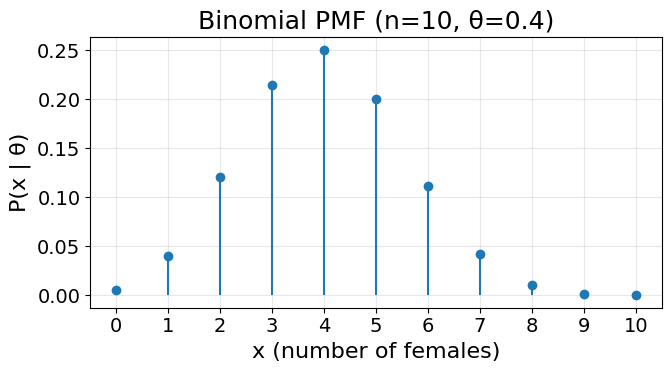

In [ ]:
# Binomial likelihood: P(x females out of n births) given birth probability theta
from scipy.stats import binom

theta = 0.4
n     = 10
x     = np.arange(0, n + 1)
pmf   = binom.pmf(x, n, theta)

plt.figure(figsize=(7, 4))
plt.stem(x, pmf, basefmt=' ')
plt.xlabel('x (number of females)')
plt.ylabel('P(x | θ)')
plt.title(f'Binomial PMF (n={n}, θ={theta})')
plt.xticks(x)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Inverse estimation

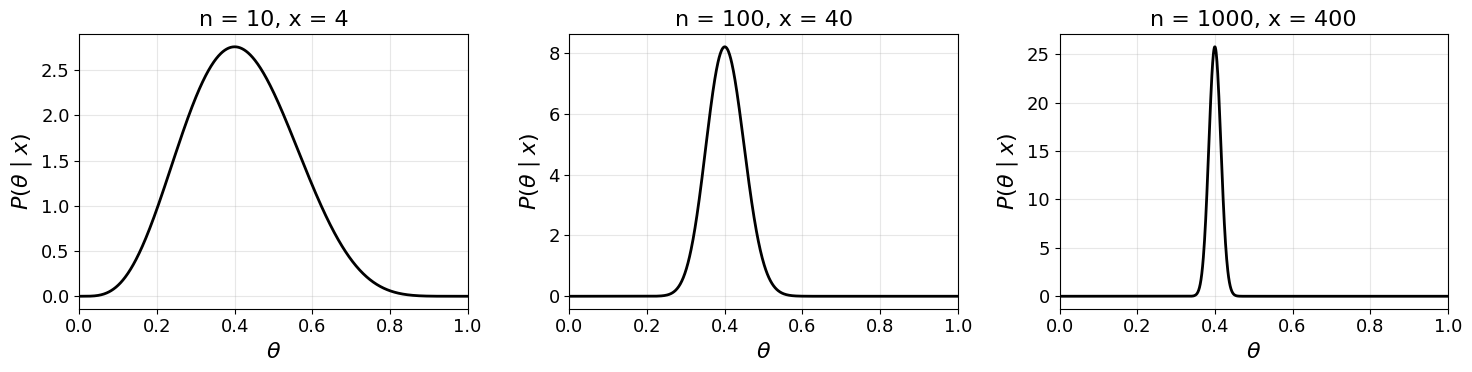

In [ ]:
# Bayesian inverse estimation: posterior P(theta | x) via Beta distribution.
# As n grows the posterior concentrates toward the true theta.
from scipy.stats import beta

cases = [(10, 4), (100, 40), (1000, 400)]   # (n, x) pairs
theta_grid = np.linspace(0, 1, 1000)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (n, x) in zip(axes, cases):
    posterior = beta.pdf(theta_grid, x + 1, n - x + 1)
    ax.plot(theta_grid, posterior, "k", linewidth=2)
    ax.set_xlim(0, 1)
    ax.set_xticks(np.arange(0, 1.01, 0.2))
    ax.set_xlabel(r"$\theta$", fontsize=16)
    ax.set_ylabel(r"$P(\theta \mid x)$", fontsize=16)
    ax.set_title(f"n = {n}, x = {x}", fontsize=16)
    ax.tick_params(labelsize=13)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Bayesian 2 class, 1 feature

### Generate samples

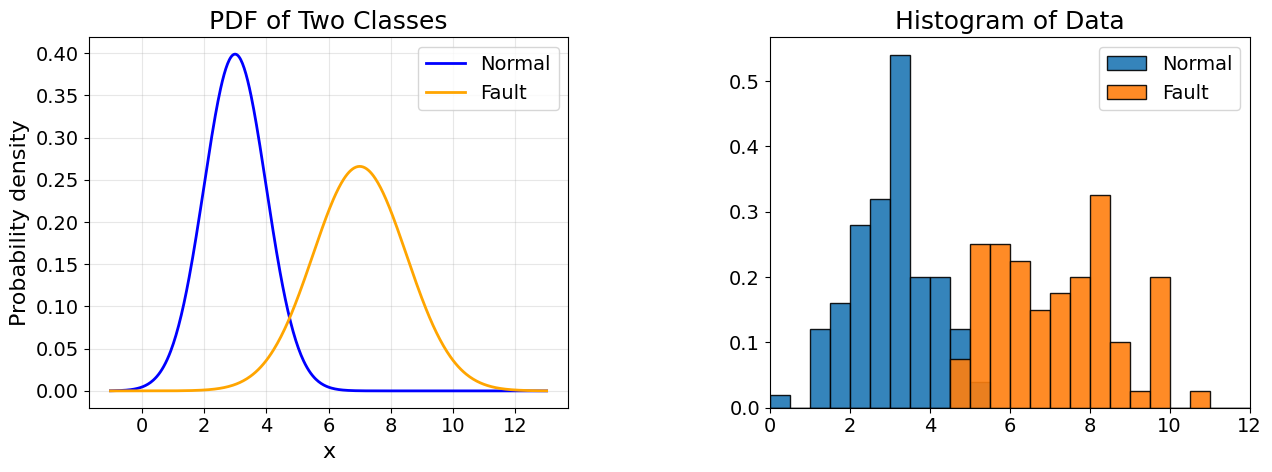

In [ ]:
# Two Gaussian classes: Normal (w1) and Fault (w2)
mu1, sigma1, n1 = 3, 1.0, 100     # Normal class
mu2, sigma2, n2 = 7, 1.5,  80     # Fault class

np.random.seed(0)   # fixed seed for reproducible synthetic data
x1 = np.random.normal(mu1, sigma1, n1)
x2 = np.random.normal(mu2, sigma2, n2)

x_axis = np.linspace(-1, 13, 500)
pdf1   = norm.pdf(x_axis, mu1, sigma1)
pdf2   = norm.pdf(x_axis, mu2, sigma2)
bins   = np.arange(0, 13, 0.5)

# 3-column layout: [left plot | spacer | right plot]
fig = plt.figure(figsize=(13, 5))
gs  = fig.add_gridspec(1, 3, width_ratios=[1, 0.15, 1])
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[2])

ax0.plot(x_axis, pdf1, 'b', linewidth=2, label='Normal')
ax0.plot(x_axis, pdf2, color='orange', linewidth=2, label='Fault')
ax0.set_xlabel('x');  ax0.set_ylabel('Probability density')
ax0.set_title('PDF of Two Classes');  ax0.legend();  ax0.grid(True, alpha=0.3)

ax1.hist(x1, bins=bins, density=True, color='tab:blue',   edgecolor='black', alpha=0.9, label='Normal')
ax1.hist(x2, bins=bins, density=True, color='tab:orange', edgecolor='black', alpha=0.9, label='Fault')
ax1.set_xlim(0, 12)
ax1.set_title('Histogram of Data');  ax1.legend()

plt.tight_layout();  plt.show()


### Bayesian classification

Estimated parameters
  w1: mean = 3.060, std = 1.008
  w2: mean = 7.203,  std = 1.506

Classification results

x = 4.5, No prior  |  P(w1|x) = 0.7293,  P(w2|x) = 0.2707  →  Normal (w1)

x = 4.5, With prior  |  P(w1|x) = 0.9604,  P(w2|x) = 0.0396  →  Normal (w1)

x = 5.5, No prior  |  P(w1|x) = 0.1312,  P(w2|x) = 0.8688  →  Fault (w2)

x = 5.5, With prior  |  P(w1|x) = 0.5762,  P(w2|x) = 0.4238  →  Normal (w1)


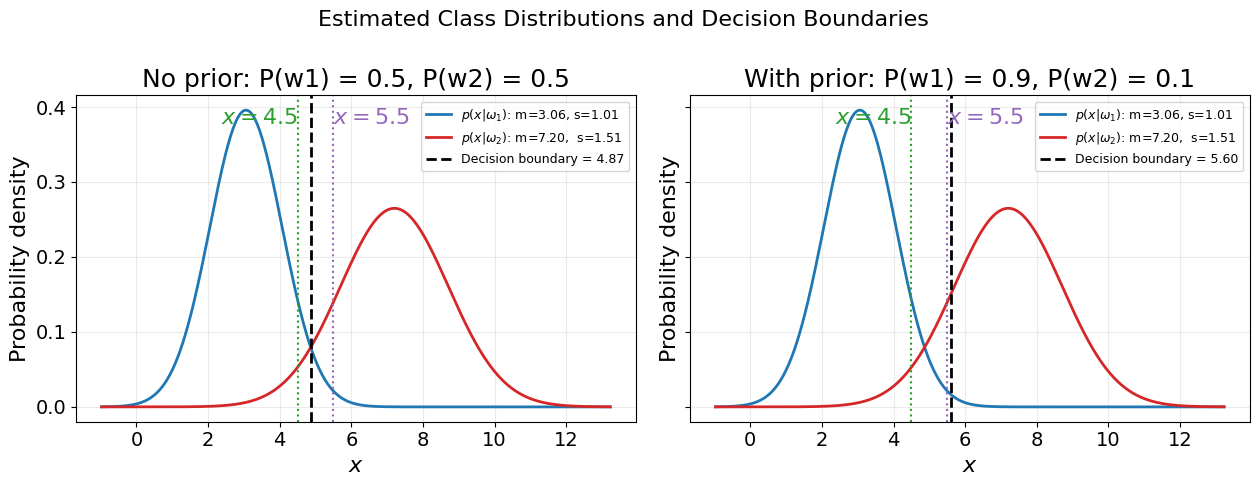

In [ ]:
# Estimate Gaussian parameters from the generated samples
normal_mean, normal_std = np.mean(x1), np.std(x1)
fault_mean,  fault_std  = np.mean(x2), np.std(x2)

print("Estimated parameters")
print(f"  w1: mean = {normal_mean:.3f}, std = {normal_std:.3f}")
print(f"  w2: mean = {fault_mean:.3f},  std = {fault_std:.3f}")


def bayes_classify(x, p_w1, p_w2):
    # Returns (posterior_w1, posterior_w2, predicted_class_string)
    score_w1 = norm.pdf(x, normal_mean, normal_std) * p_w1
    score_w2 = norm.pdf(x, fault_mean,  fault_std)  * p_w2
    posterior_w1 = score_w1 / (score_w1 + score_w2)
    posterior_w2 = score_w2 / (score_w1 + score_w2)
    predicted = "Normal (w1)" if posterior_w1 > posterior_w2 else "Fault (w2)"
    return posterior_w1, posterior_w2, predicted


def decision_boundary(p_w1, p_w2):
    # Solve the quadratic Bayesian decision boundary between two Gaussians
    a = 1 / fault_std**2 - 1 / normal_std**2
    b = 2 * normal_mean / normal_std**2 - 2 * fault_mean / fault_std**2
    c = (fault_mean**2 / fault_std**2 - normal_mean**2 / normal_std**2
         + 2 * np.log(p_w1 * fault_std / (p_w2 * normal_std)))
    if np.isclose(a, 0):   # linear case when variances are equal
        return -c / b
    discriminant = b**2 - 4 * a * c
    if discriminant < 0:
        return None
    roots = np.array([(-b + np.sqrt(discriminant)) / (2 * a),
                      (-b - np.sqrt(discriminant)) / (2 * a)])
    lo, hi = min(normal_mean, fault_mean), max(normal_mean, fault_mean)
    valid  = roots[(roots >= lo) & (roots <= hi)]
    if len(valid) > 0:
        return valid[0]
    midpoint = 0.5 * (normal_mean + fault_mean)
    return roots[np.argmin(np.abs(roots - midpoint))]


# Four classification cases: two test points x two prior settings
print("\nClassification results")
for x in [4.5, 5.5]:
    for case_name, p_w1, p_w2 in [("No prior", 0.5, 0.5), ("With prior", 0.9, 0.1)]:
        pw1, pw2, pred = bayes_classify(x, p_w1, p_w2)
        print(f"\nx = {x}, {case_name}  |  P(w1|x) = {pw1:.4f},  P(w2|x) = {pw2:.4f}  →  {pred}")

# Plot both prior cases side by side
x_plot = np.linspace(min(normal_mean - 4*normal_std, fault_mean - 4*fault_std),
                     max(normal_mean + 4*normal_std, fault_mean + 4*fault_std), 1000)
pdf_w1 = norm.pdf(x_plot, normal_mean, normal_std)
pdf_w2 = norm.pdf(x_plot, fault_mean,  fault_std)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, (p_w1, p_w2, title) in zip(axes, [
    (0.5, 0.5, "No prior: P(w1) = 0.5, P(w2) = 0.5"),
    (0.9, 0.1, "With prior: P(w1) = 0.9, P(w2) = 0.1")
]):
    boundary = decision_boundary(p_w1, p_w2)
    ax.plot(x_plot, pdf_w1, color="tab:blue", linewidth=2,
            label=fr"$p(x|\omega_1)$: m={normal_mean:.2f}, s={normal_std:.2f}")
    ax.plot(x_plot, pdf_w2, color="tab:red",  linewidth=2,
            label=fr"$p(x|\omega_2)$: m={fault_mean:.2f},  s={fault_std:.2f}")
    ax.axvline(boundary, color="black", linestyle="--", linewidth=2,
               label=fr"Decision boundary = {boundary:.2f}")
    for xv, col, txt in [(4.5, "tab:green", "$x=4.5$"), (5.5, "tab:purple", "$x=5.5$")]:
        ax.axvline(xv, color=col, linestyle=":", linewidth=1.5)
        ax.text(xv, ax.get_ylim()[1]*0.96, txt, color=col,
                ha="right" if xv < 5 else "left", va="top")
    ax.set_title(title);  ax.set_xlabel("$x$");  ax.set_ylabel("Probability density")
    ax.grid(alpha=0.25);  ax.legend(fontsize=9)
fig.suptitle("Estimated Class Distributions and Decision Boundaries", fontsize=16)
plt.tight_layout();  plt.show()


## Bayesian 2 class, 2 features

### Generate samples

Run **once** to create the .mat files. Skip if `Simulation_2features_train.mat` and `_test.mat` are already in the datasets folder.

In [ ]:
# True distribution parameters
mean_1 = np.array([2.6, 3.2]);  cov_1 = np.array([[3.4, -1.2], [-1.2, 1.0]])
mean_2 = np.array([7.0, 5.0]);  cov_2 = np.array([[2.6, -0.8], [-0.8, 0.8]])

# Training data: 50 samples per class, seed=42
np.random.seed(42)
x1_train = np.random.multivariate_normal(mean_1, cov_1, size=50)
x2_train = np.random.multivariate_normal(mean_2, cov_2, size=50)
x_train  = np.vstack((x1_train, x2_train))
label_train = np.vstack((np.ones((50,1)), 2*np.ones((50,1)))).astype(int)

# Test data: 20 samples per class, seed=125 (chosen to give exactly 2 misclassifications)
np.random.seed(125)
x1_test = np.random.multivariate_normal(mean_1, cov_1, size=20)
x2_test = np.random.multivariate_normal(mean_2, cov_2, size=20)
x_test  = np.vstack((x1_test, x2_test))
label_test_gen = np.vstack((np.ones((20,1)), 2*np.ones((20,1)))).astype(int)

# Uncomment to save (one-time operation):
# savemat(DATA_ROOT / "Simulation_2features_train.mat", {"x": x_train, "label": label_train})
# savemat(DATA_ROOT / "Simulation_2features_test.mat",  {"x": x_test,  "label": label_test_gen})
# print("Saved training and test data.")


### Read training data


Class 1: Normal
---------------------------------------------------------
Given                       Estimated
---------------------------------------------------------
Mean
[2.6 3.2]                   [2.6266 3.1666]

Covariance
[ 3.4 -1.2]                 [ 3.4084 -1.2397]
[-1.2  1. ]                 [-1.2397  1.0384]

Class 2: Fault
---------------------------------------------------------
Given                       Estimated
---------------------------------------------------------
Mean
[7. 5.]                     [6.9774 4.9571]

Covariance
[ 2.6 -0.8]                 [ 2.6608 -0.8208]
[-0.8  0.8]                 [-0.8208  0.7952]


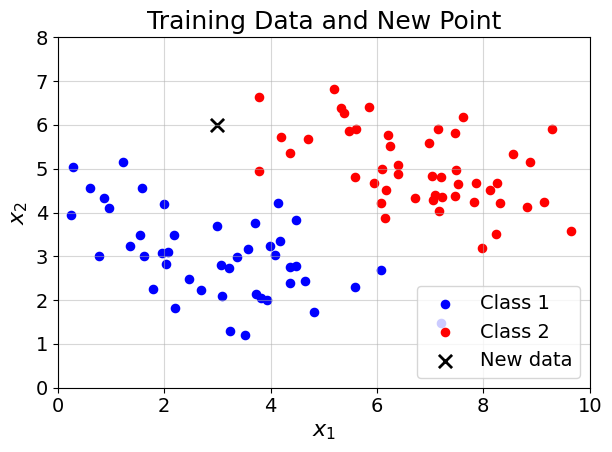

In [ ]:
data  = loadmat(DATA_ROOT / "Simulation_2features_train.mat")
x     = data["x"]
label = data["label"].ravel()

# True distribution parameters (for comparison)
mean_true_1 = np.array([2.6, 3.2]);  cov_true_1 = np.array([[3.4, -1.2], [-1.2, 1.0]])
mean_true_2 = np.array([7.0, 5.0]);  cov_true_2 = np.array([[2.6, -0.8], [-0.8, 0.8]])

x1 = x[label == 1];  x2 = x[label == 2]

# Estimated parameters
mean_est_1 = np.mean(x1, axis=0);  cov_est_1 = np.cov(x1, rowvar=False)
mean_est_2 = np.mean(x2, axis=0);  cov_est_2 = np.cov(x2, rowvar=False)

def print_comparison(class_name, mean_given, mean_est, cov_given, cov_est):
    print(f"\n{class_name}")
    print("-" * 57)
    print(f"{'Given':<28}{'Estimated'}")
    print("-" * 57)
    print("Mean")
    print(f"{str(mean_given):<28}{np.array2string(mean_est, precision=4)}")
    print("\nCovariance")
    for g_row, e_row in zip(cov_given, cov_est):
        print(f"{np.array2string(g_row, precision=4):<28}{np.array2string(e_row, precision=4)}")

print_comparison("Class 1: Normal", mean_true_1, mean_est_1, cov_true_1, cov_est_1)
print_comparison("Class 2: Fault",  mean_true_2, mean_est_2, cov_true_2, cov_est_2)

new_x = np.array([3.0, 6.0])
plt.figure()
plt.scatter(x1[:, 0], x1[:, 1], color="blue", s=35, label="Class 1")
plt.scatter(x2[:, 0], x2[:, 1], color="red",  s=35, label="Class 2")
plt.scatter(new_x[0], new_x[1], color="black", marker="x", s=90, linewidth=2, label="New data")
plt.xlabel("$x_1$");  plt.ylabel("$x_2$")
plt.xlim(0, 10);  plt.ylim(0, 8)
plt.grid(True, alpha=0.5);  plt.legend(loc="lower right")
plt.title("Training Data and New Point")
plt.tight_layout();  plt.show()


### Find test seed (one-time utility)

This cell was used once to discover seed=125 for the test dataset above. Skip when the .mat files already exist.

In [ ]:
# Search for a seed giving exactly 2 misclassifications on 40 test samples (result: 125).
for seed in range(1000):
    if seed == 42:   # exclude the training seed
        continue
    np.random.seed(seed)
    x1_t = np.random.multivariate_normal(mean_1, cov_1, size=20)
    x2_t = np.random.multivariate_normal(mean_2, cov_2, size=20)
    x_t   = np.vstack((x1_t, x2_t))
    lbl_t = np.hstack((np.ones(20), 2*np.ones(20))).astype(int)
    s1 = multivariate_normal.pdf(x_t, mean=mean_est_1, cov=cov_est_1) * 0.5
    s2 = multivariate_normal.pdf(x_t, mean=mean_est_2, cov=cov_est_2) * 0.5
    n_wrong = np.sum(lbl_t != np.where(s1 > s2, 1, 2))
    if n_wrong == 2:
        print(f"Selected seed: {seed},  Misclassifications: {n_wrong}")
        break


Selected seed: 125,  Misclassifications: 2


### Apply to a data

New data x = [3. 6.]
Distance to Class 1 center = 2.8579
Distance to Class 2 center = 4.1119
P(Class 1 | x) = 0.0092,  P(Class 2 | x) = 0.9908
Bayesian classification → Class 2


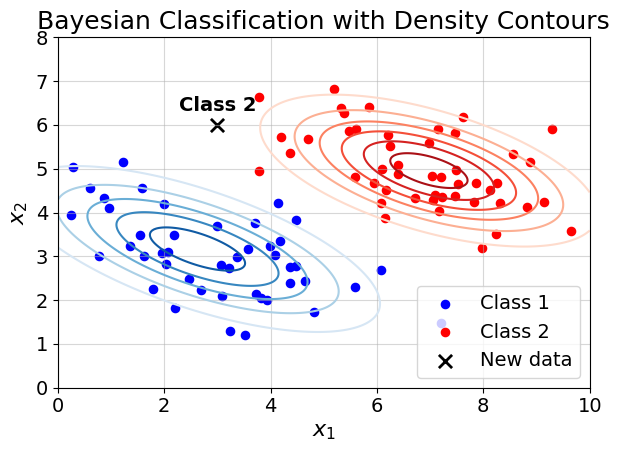

In [ ]:
# Bayesian classification of a new data point with equal priors
prior_1, prior_2 = 0.5, 0.5

likelihood_1 = multivariate_normal.pdf(new_x, mean_est_1, cov_est_1)
likelihood_2 = multivariate_normal.pdf(new_x, mean_est_2, cov_est_2)
score_1 = likelihood_1 * prior_1;  score_2 = likelihood_2 * prior_2
posterior_1 = score_1 / (score_1 + score_2)
posterior_2 = score_2 / (score_1 + score_2)
predicted_class = 1 if posterior_1 > posterior_2 else 2

print(f"New data x = {new_x}")
print(f"Distance to Class 1 center = {np.linalg.norm(new_x - mean_est_1):.4f}")
print(f"Distance to Class 2 center = {np.linalg.norm(new_x - mean_est_2):.4f}")
print(f"P(Class 1 | x) = {posterior_1:.4f},  P(Class 2 | x) = {posterior_2:.4f}")
print(f"Bayesian classification → Class {predicted_class}")

# Density contour plot
x_axis = np.linspace(0, 10, 300);  y_axis = np.linspace(0, 8, 300)
xx, yy = np.meshgrid(x_axis, y_axis)
grid   = np.column_stack((xx.ravel(), yy.ravel()))
pdf_1  = multivariate_normal.pdf(grid, mean_est_1, cov_est_1).reshape(xx.shape)
pdf_2  = multivariate_normal.pdf(grid, mean_est_2, cov_est_2).reshape(xx.shape)

plt.figure()
plt.scatter(x1[:, 0], x1[:, 1], color="blue", s=35, label="Class 1")
plt.scatter(x2[:, 0], x2[:, 1], color="red",  s=35, label="Class 2")
plt.scatter(new_x[0], new_x[1], color="black", marker="x", s=90, linewidth=2, label="New data")
plt.contour(xx, yy, pdf_1, levels=6, cmap="Blues", linewidths=1.5)
plt.contour(xx, yy, pdf_2, levels=6, cmap="Reds",  linewidths=1.5)
plt.annotate(f"Class {predicted_class}", xy=new_x, xytext=(0, 10),
             textcoords="offset points", ha="center", fontsize=14, fontweight="bold")
plt.xlabel("$x_1$");  plt.ylabel("$x_2$")
plt.xlim(0, 10);  plt.ylim(0, 8)
plt.grid(True, alpha=0.5);  plt.legend(loc="lower right")
plt.title("Bayesian Classification with Density Contours")
plt.tight_layout();  plt.show()


### Decision boundary

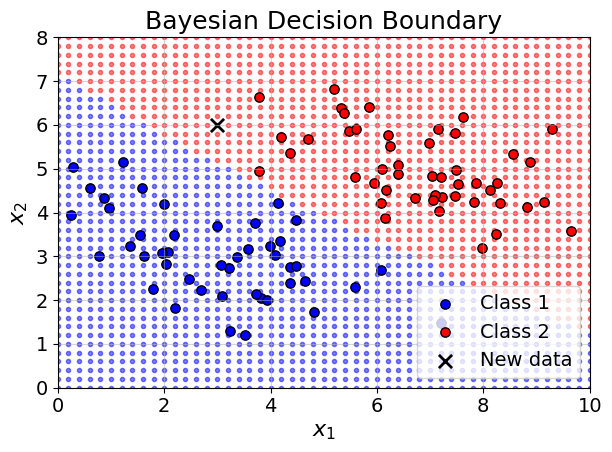

In [ ]:
# Classify a uniform grid to visualize the Bayesian decision region
x1_grid, x2_grid = np.meshgrid(np.arange(0, 10.2, 0.2), np.arange(0, 8.2, 0.2))
grid_points = np.column_stack((x1_grid.ravel(), x2_grid.ravel()))

score_grid_1 = multivariate_normal.pdf(grid_points, mean=mean_est_1, cov=cov_est_1) * prior_1
score_grid_2 = multivariate_normal.pdf(grid_points, mean=mean_est_2, cov=cov_est_2) * prior_2
grid_class   = np.where(score_grid_1 >= score_grid_2, 1, 2)

plt.figure()
plt.scatter(grid_points[grid_class == 1, 0], grid_points[grid_class == 1, 1],
            color="blue", marker=".", alpha=0.5)
plt.scatter(grid_points[grid_class == 2, 0], grid_points[grid_class == 2, 1],
            color="red",  marker=".", alpha=0.5)
plt.scatter(x1[:, 0], x1[:, 1], color="blue", s=45, edgecolors="black", label="Class 1")
plt.scatter(x2[:, 0], x2[:, 1], color="red",  s=45, edgecolors="black", label="Class 2")
plt.scatter(new_x[0], new_x[1], color="black", marker="x", s=90, linewidth=2, label="New data")
plt.xlabel("$x_1$");  plt.ylabel("$x_2$")
plt.xlim(0, 10);  plt.ylim(0, 8)
plt.grid(True, alpha=0.5);  plt.legend(loc="lower right")
plt.title("Bayesian Decision Boundary")
plt.tight_layout();  plt.show()


### Apply to test data

Test samples: 40,  Accuracy: 0.9500
Correctly classified: 38,  Misclassified: 2


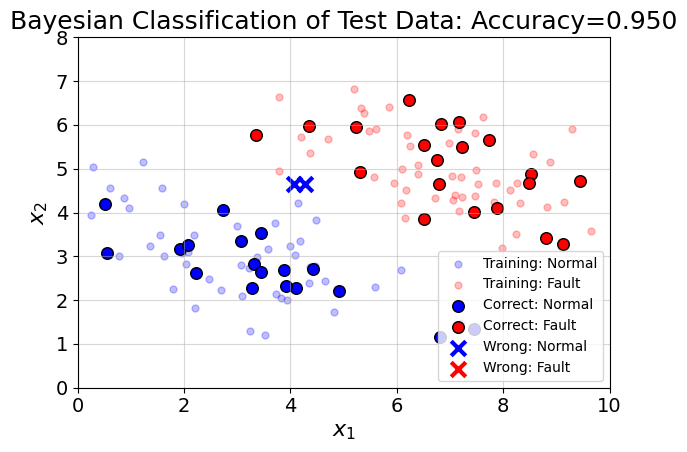

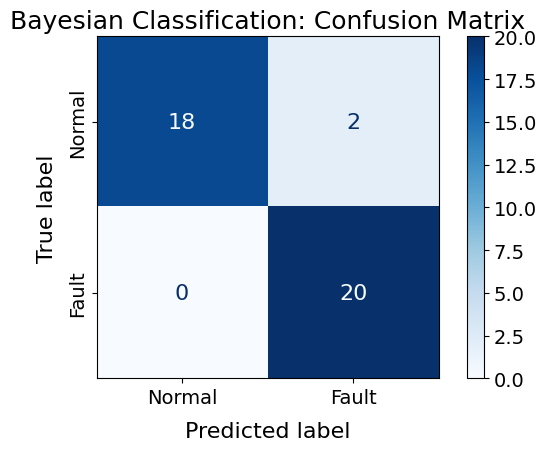

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

test_data  = loadmat(DATA_ROOT / "Simulation_2features_test.mat")
x_test     = test_data["x"]
label_test = test_data["label"].ravel()

score_1    = multivariate_normal.pdf(x_test, mean=mean_est_1, cov=cov_est_1) * prior_1
score_2    = multivariate_normal.pdf(x_test, mean=mean_est_2, cov=cov_est_2) * prior_2
label_pred = np.where(score_1 > score_2, 1, 2)
accuracy   = accuracy_score(label_test, label_pred)

correct_1 = (label_test == 1) & (label_pred == 1)
correct_2 = (label_test == 2) & (label_pred == 2)
wrong_1   = (label_test == 1) & (label_pred == 2)
wrong_2   = (label_test == 2) & (label_pred == 1)

print(f"Test samples: {len(x_test)},  Accuracy: {accuracy:.4f}")
print(f"Correctly classified: {np.sum(label_test == label_pred)},  Misclassified: {np.sum(label_test != label_pred)}")

plt.figure()
plt.scatter(x1[:, 0], x1[:, 1], color="blue", s=25, alpha=0.25, label="Training: Normal")
plt.scatter(x2[:, 0], x2[:, 1], color="red",  s=25, alpha=0.25, label="Training: Fault")
plt.scatter(x_test[correct_1, 0], x_test[correct_1, 1],
            color="blue", marker="o", s=70, edgecolor="black", label="Correct: Normal")
plt.scatter(x_test[correct_2, 0], x_test[correct_2, 1],
            color="red",  marker="o", s=70, edgecolor="black", label="Correct: Fault")
plt.scatter(x_test[wrong_1, 0], x_test[wrong_1, 1],
            color="blue", marker="x", s=110, linewidth=3, label="Wrong: Normal")
plt.scatter(x_test[wrong_2, 0], x_test[wrong_2, 1],
            color="red",  marker="x", s=110, linewidth=3, label="Wrong: Fault")
plt.xlabel("$x_1$");  plt.ylabel("$x_2$")
plt.xlim(0, 10);  plt.ylim(0, 8)
plt.grid(True, alpha=0.5);  plt.legend(loc="lower right", fontsize=10)
plt.title(f"Bayesian Classification of Test Data: Accuracy={accuracy:.3f}")
plt.tight_layout();  plt.show()

cm   = confusion_matrix(label_test, label_pred, labels=[1, 2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Fault"])
disp.plot(cmap="Blues", values_format="d")
disp.ax_.set_yticklabels(["Normal", "Fault"], rotation=90, va="center")
disp.ax_.set_ylabel("True label", rotation=90, labelpad=8)
disp.ax_.set_xlabel("Predicted label", labelpad=10)
plt.title("Bayesian Classification: Confusion Matrix")
plt.tight_layout();  plt.show()


# Machine learning method

## kNN 2 class, 2 features

### Apply to a data

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

new_x_point = np.array([[3.0, 6.0]])
k_values    = [3, 5, 7, 9, 11, 13]

print(f"New data: {new_x_point[0]}")
print("-" * 45)
print(f"{'k':<5}{'Class 1 votes':<16}{'Class 2 votes':<16}{'Predicted'}")
print("-" * 45)

for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(x, label)
    predicted      = knn_k.predict(new_x_point)[0]
    neighbor_lbls  = label[knn_k.kneighbors(new_x_point, return_distance=False)[0]]
    votes_1 = np.sum(neighbor_lbls == 1)
    votes_2 = np.sum(neighbor_lbls == 2)
    print(f"{k:<5}{votes_1:<16}{votes_2:<16}Class {predicted}")


New data: [3. 6.]
---------------------------------------------
k    Class 1 votes   Class 2 votes   Predicted
---------------------------------------------
3    0               3               Class 2
5    0               5               Class 2
7    2               5               Class 2
9    4               5               Class 2
11   5               6               Class 2
13   6               7               Class 2


### Decision boundary

New data = [3. 6.],  Predicted class = Class 2


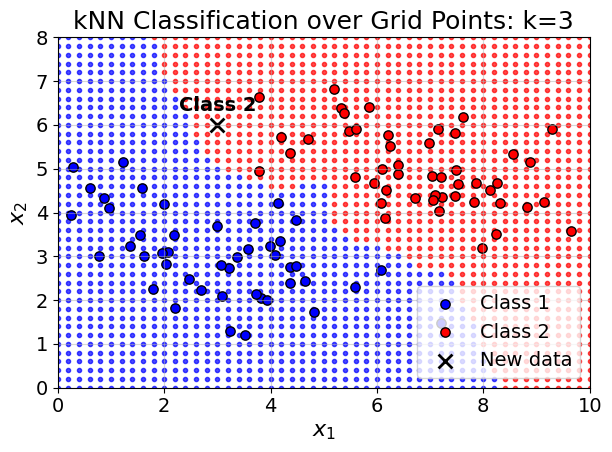

In [ ]:
k   = 3
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(x, label)

new_x_point     = np.array([[3.0, 6.0]])
predicted_class = knn.predict(new_x_point)[0]
print(f"New data = {new_x_point[0]},  Predicted class = Class {predicted_class}")

x_axis = np.arange(0, 10.2, 0.2);  y_axis = np.arange(0, 8.2, 0.2)
xx, yy = np.meshgrid(x_axis, y_axis)
grid_points = np.column_stack((xx.ravel(), yy.ravel()))
grid_class  = knn.predict(grid_points)

plt.figure()
plt.scatter(grid_points[grid_class == 1, 0], grid_points[grid_class == 1, 1],
            color="blue", marker=".", alpha=0.7)
plt.scatter(grid_points[grid_class == 2, 0], grid_points[grid_class == 2, 1],
            color="red",  marker=".", alpha=0.7)
plt.scatter(x1[:, 0], x1[:, 1], color="blue", s=45, edgecolors="black", label="Class 1")
plt.scatter(x2[:, 0], x2[:, 1], color="red",  s=45, edgecolors="black", label="Class 2")
plt.scatter(new_x_point[0, 0], new_x_point[0, 1], color="black", marker="x",
            s=100, linewidth=2, label="New data")
plt.annotate(f"Class {predicted_class}", xy=new_x_point[0], xytext=(0, 10),
             textcoords="offset points", ha="center", fontsize=14, fontweight="bold")
plt.xlabel("$x_1$");  plt.ylabel("$x_2$")
plt.xlim(0, 10);  plt.ylim(0, 8)
plt.grid(True, alpha=0.5);  plt.legend(loc="lower right")
plt.title(f"kNN Classification over Grid Points: k={k}")
plt.tight_layout();  plt.show()


### Apply to test data

k = 3,  Test samples = 40,  Accuracy = 0.9500


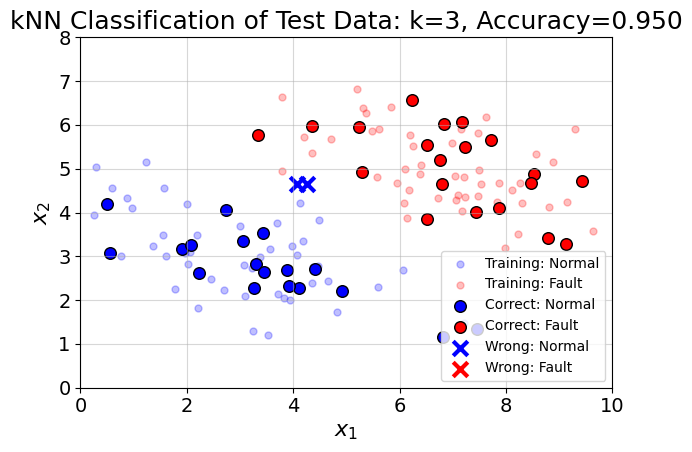

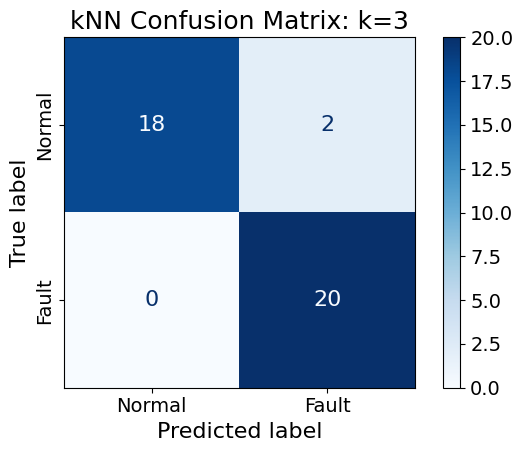

In [ ]:
k   = 3
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(x, label)

test_data  = loadmat(DATA_ROOT / "Simulation_2features_test.mat")
x_test     = test_data["x"]
label_test = test_data["label"].ravel()

label_pred = knn.predict(x_test)
accuracy   = accuracy_score(label_test, label_pred)

correct_1 = (label_test == 1) & (label_pred == 1)
correct_2 = (label_test == 2) & (label_pred == 2)
wrong_1   = (label_test == 1) & (label_pred == 2)
wrong_2   = (label_test == 2) & (label_pred == 1)

print(f"k = {k},  Test samples = {len(x_test)},  Accuracy = {accuracy:.4f}")

plt.figure()
plt.scatter(x1[:, 0], x1[:, 1], color="blue", s=25, alpha=0.25, label="Training: Normal")
plt.scatter(x2[:, 0], x2[:, 1], color="red",  s=25, alpha=0.25, label="Training: Fault")
plt.scatter(x_test[correct_1, 0], x_test[correct_1, 1],
            color="blue", marker="o", s=70, edgecolor="black", label="Correct: Normal")
plt.scatter(x_test[correct_2, 0], x_test[correct_2, 1],
            color="red",  marker="o", s=70, edgecolor="black", label="Correct: Fault")
plt.scatter(x_test[wrong_1, 0], x_test[wrong_1, 1],
            color="blue", marker="x", s=110, linewidth=3, label="Wrong: Normal")
plt.scatter(x_test[wrong_2, 0], x_test[wrong_2, 1],
            color="red",  marker="x", s=110, linewidth=3, label="Wrong: Fault")
plt.xlabel("$x_1$");  plt.ylabel("$x_2$")
plt.xlim(0, 10);  plt.ylim(0, 8)
plt.grid(True, alpha=0.5);  plt.legend(loc="lower right", fontsize=10)
plt.title(f"kNN Classification of Test Data: k={k}, Accuracy={accuracy:.3f}")
plt.tight_layout();  plt.show()

cm   = confusion_matrix(label_test, label_pred, labels=[1, 2])
disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Fault"])
disp.plot(cmap="Blues", values_format="d")
disp.ax_.set_yticklabels(["Normal", "Fault"], rotation=90, va="center")
plt.title(f"kNN Confusion Matrix: k={k}")
plt.tight_layout();  plt.show()


## ANN of 2 class, 2 features

### Train ANN

Epoch [100/1000]  Train: 0.3713  Val: 0.3665
Epoch [200/1000]  Train: 0.0878  Val: 0.1309
Epoch [300/1000]  Train: 0.0237  Val: 0.0728
Epoch [400/1000]  Train: 0.0117  Val: 0.0596
Epoch [500/1000]  Train: 0.0072  Val: 0.0536
Epoch [600/1000]  Train: 0.0049  Val: 0.0506
Epoch [700/1000]  Train: 0.0036  Val: 0.0485
Epoch [800/1000]  Train: 0.0027  Val: 0.0474

Early stopping at epoch 848
Best epoch = 828,  Val loss = 0.046458
Training accuracy = 1.0000,  Validation = 0.9667,  Total = 0.9900


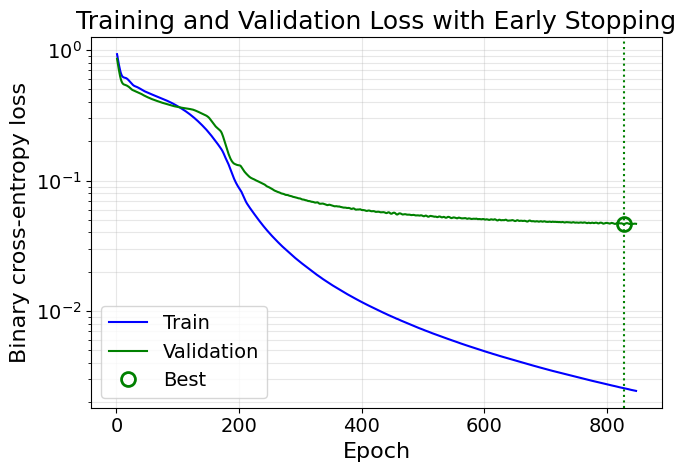

In [ ]:
# 2-class ANN: 2 inputs → 10 ReLU → 1 Sigmoid (binary cross-entropy)
data = loadmat(DATA_ROOT / "Simulation_2features_train.mat")
XY    = data["x"].T
label = data["label"].ravel()
c     = (label == 1).astype(float)   # Class 1 → 1, Class 2 → 0

XY_tensor = torch.FloatTensor(XY.T)
c_tensor  = torch.FloatTensor(c).unsqueeze(1)

X_train, X_val, y_train, y_val = train_test_split(
    XY_tensor, c_tensor, test_size=0.3, random_state=4, stratify=c_tensor
)

num_nodes = 10

class Net2Class(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1     = nn.Linear(2, num_nodes)
        self.fc2     = nn.Linear(num_nodes, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        return self.sigmoid(self.fc2(torch.relu(self.fc1(x))))

net2      = Net2Class()
criterion = nn.BCELoss()
optimizer = optim.Adam(net2.parameters(), lr=0.01)

num_epochs = 1000;  patience = 20
train_losses, val_losses = [], []
best_val_loss = float("inf");  best_epoch = 0
best_state = copy.deepcopy(net2.state_dict());  counter = 0

for epoch in range(num_epochs):
    net2.train()
    train_loss = criterion(net2(X_train), y_train)
    optimizer.zero_grad();  train_loss.backward();  optimizer.step()

    net2.eval()
    with torch.no_grad():
        val_loss = criterion(net2(X_val), y_val)

    train_losses.append(train_loss.item());  val_losses.append(val_loss.item())

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}]  Train: {train_loss.item():.4f}  Val: {val_loss.item():.4f}")

    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item();  best_epoch = epoch + 1
        best_state = copy.deepcopy(net2.state_dict());  counter = 0
    else:
        counter += 1
    if counter >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

net2.load_state_dict(best_state);  net2.eval()

with torch.no_grad():
    train_acc = ((net2(X_train) >= 0.5) == y_train).float().mean().item()
    val_acc   = ((net2(X_val)   >= 0.5) == y_val  ).float().mean().item()
    total_acc = ((net2(XY_tensor) >= 0.5) == c_tensor).float().mean().item()

print(f"Best epoch = {best_epoch},  Val loss = {best_val_loss:.6f}")
print(f"Training accuracy = {train_acc:.4f},  Validation = {val_acc:.4f},  Total = {total_acc:.4f}")

epochs_arr = np.arange(1, len(train_losses) + 1)
plt.figure(figsize=(7, 5))
plt.semilogy(epochs_arr, train_losses, "b-", label="Train")
plt.semilogy(epochs_arr, val_losses,   "g-", label="Validation")
plt.axvline(best_epoch, color="g", linestyle=":", linewidth=1.5)
plt.plot(best_epoch, best_val_loss, "go", markersize=10,
         markerfacecolor="none", markeredgewidth=2, label="Best")
plt.xlabel("Epoch");  plt.ylabel("Binary cross-entropy loss")
plt.title("Training and Validation Loss with Early Stopping")
plt.legend();  plt.grid(True, which="both", alpha=0.3)
plt.tight_layout();  plt.show()


### Decision boundary

New data = [3. 6.]
P(Class 1) = 0.0869,  P(Class 2) = 0.9131
Predicted class = Class 2


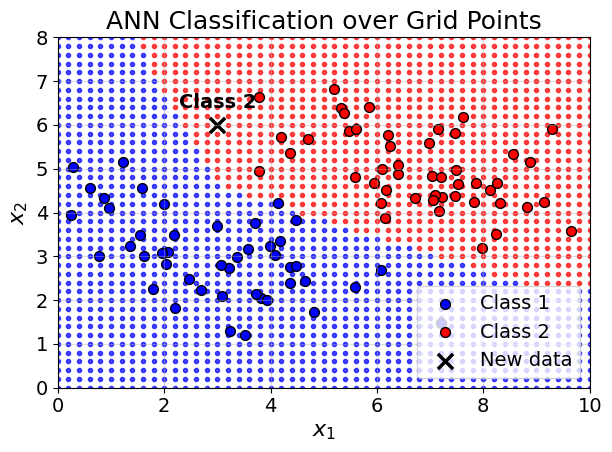

In [ ]:
new_x_single = np.array([3.0, 6.0])

net2.eval()
with torch.no_grad():
    probability = net2(torch.FloatTensor(new_x_single).unsqueeze(0)).item()

predicted_class = 1 if probability > 0.5 else 2
print(f"New data = {new_x_single}")
print(f"P(Class 1) = {probability:.4f},  P(Class 2) = {1-probability:.4f}")
print(f"Predicted class = Class {predicted_class}")

x1_grid, x2_grid = np.meshgrid(np.arange(0, 10.2, 0.2), np.arange(0, 10.2, 0.2))
grid = np.column_stack((x1_grid.ravel(), x2_grid.ravel()))
with torch.no_grad():
    grid_prob = net2(torch.FloatTensor(grid)).numpy().flatten()

plt.figure()
plt.scatter(grid[grid_prob > 0.5, 0], grid[grid_prob > 0.5, 1],
            color="blue", marker=".", alpha=0.7)
plt.scatter(grid[grid_prob <= 0.5, 0], grid[grid_prob <= 0.5, 1],
            color="red",  marker=".", alpha=0.7)
plt.scatter(XY[0, c == 1], XY[1, c == 1],
            color="blue", s=50, edgecolors="black", label="Class 1")
plt.scatter(XY[0, c == 0], XY[1, c == 0],
            color="red",  s=50, edgecolors="black", label="Class 2")
plt.scatter(new_x_single[0], new_x_single[1], color="black", marker="x",
            s=120, linewidth=2.5, label="New data")
plt.annotate(f"Class {predicted_class}", xy=new_x_single, xytext=(0, 12),
             textcoords="offset points", ha="center", fontsize=14, fontweight="bold")
plt.xlabel("$x_1$");  plt.ylabel("$x_2$")
plt.xlim(0, 10);  plt.ylim(0, 8)
plt.title("ANN Classification over Grid Points")
plt.legend(loc="lower right");  plt.grid(True, alpha=0.4)
plt.tight_layout();  plt.show()


### Apply to test data

Test accuracy = 0.9500


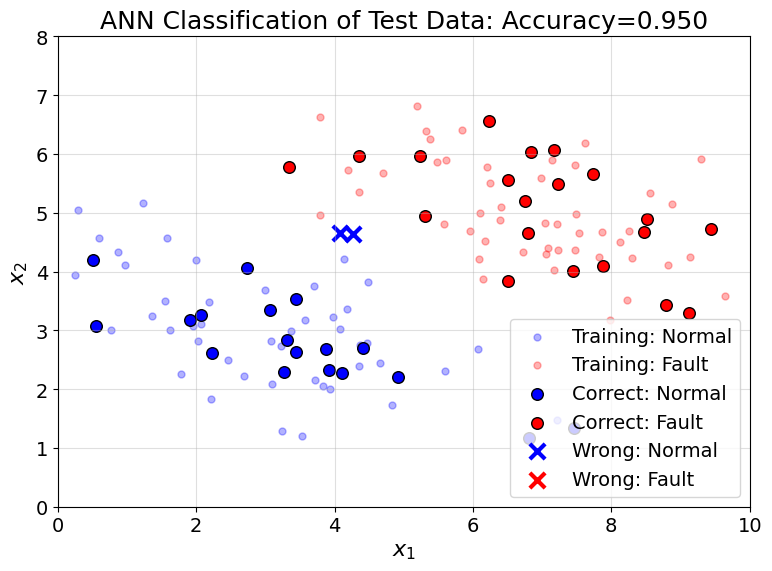

In [ ]:
test_path  = DATA_ROOT / "Simulation_2features_test.mat"
test_data  = loadmat(test_path)
x_test     = test_data["x"]
label_test = test_data["label"].ravel()

net2.eval()
with torch.no_grad():
    test_prob = net2(torch.FloatTensor(x_test)).numpy().flatten()

test_pred     = np.where(test_prob >= 0.5, 1, 2)
test_accuracy = np.mean(test_pred == label_test)
print(f"Test accuracy = {test_accuracy:.4f}")

correct_normal = (label_test == 1) & (test_pred == 1)
correct_fault  = (label_test == 2) & (test_pred == 2)
wrong_normal   = (label_test == 1) & (test_pred == 2)
wrong_fault    = (label_test == 2) & (test_pred == 1)

plt.figure(figsize=(8, 6))
plt.scatter(x1[:, 0], x1[:, 1], color="blue", s=25, alpha=0.3, label="Training: Normal")
plt.scatter(x2[:, 0], x2[:, 1], color="red",  s=25, alpha=0.3, label="Training: Fault")
plt.scatter(x_test[correct_normal, 0], x_test[correct_normal, 1],
            color="blue", marker="o", s=70, edgecolors="black", label="Correct: Normal")
plt.scatter(x_test[correct_fault, 0], x_test[correct_fault, 1],
            color="red",  marker="o", s=70, edgecolors="black", label="Correct: Fault")
plt.scatter(x_test[wrong_normal, 0], x_test[wrong_normal, 1],
            color="blue", marker="x", s=120, linewidth=3, label="Wrong: Normal")
plt.scatter(x_test[wrong_fault, 0], x_test[wrong_fault, 1],
            color="red",  marker="x", s=120, linewidth=3, label="Wrong: Fault")
plt.xlabel("$x_1$");  plt.ylabel("$x_2$")
plt.xlim(0, 10);  plt.ylim(0, 8)
plt.title(f"ANN Classification of Test Data: Accuracy={test_accuracy:.3f}")
plt.legend(loc="lower right");  plt.grid(True, alpha=0.4)
plt.tight_layout();  plt.show()


## ANN of RK4 Kit Using J3-Selected Features

From 11 time-domain and 9 frequency-domain features, select 10 using correlation-constrained J3. Perform seven-condition diagnosis with a basic ANN.

Frequency-domain features are loaded from `RK4_feat_domain.mat`. Time-domain features are extracted from `RK4_raw.mat` and saved as `RK4_feat_time.mat`.

### Settings

In [ ]:
RK4_ROOT    = DATA_ROOT / "RK4_Rotor_Kit"
raw_file    = RK4_ROOT / "RK4_raw.mat"
time_file   = RK4_ROOT / "RK4_feat_time.mat"
domain_file = RK4_ROOT / "RK4_feat_domain.mat"

time_feature_names = ["MEAN","STD","RMS","SK","KUR","SF","CF","IF","MF","PEAK","P2P"]
domain_feature_names = [
    "Shaft 1X", "Shaft 2X", "Shaft 3X",
    "BPFI-1X", "BPFI", "BPFI+1X",
    "BPFO 1X", "BPFO 2X", "BPFO 3X"
]
class_variables = {
    "Normal":          ("Nor",   "FNor"),
    "Unbalance 35":    ("Unb35", "FUnb35"),
    "Unbalance 45":    ("Unb45", "FUnb45"),
    "Misalignment 06": ("Mis06", "FMis06"),
    "Misalignment 08": ("Mis08", "FMis08"),
    "Bearing inner":   ("Bin",   "FBin"),
    "Bearing outer":   ("Bout",  "FBout")
}
feature_names = time_feature_names + domain_feature_names

n_set              = 20
n_per_set          = 12800
n_selected_features = 10
correlation_limit  = 0.95
test_ratio         = 0.30
validation_ratio   = 0.20
random_state       = 42


### Extract time-domain features

In [ ]:
# Extract 11 time-domain features per measurement set.
# time_features() is defined in Shared utility functions.
raw = loadmat(raw_file)
time_data = {}

for class_name, (raw_name, feat_name) in class_variables.items():
    x_all = np.asarray(raw[raw_name], dtype=float).ravel()
    if x_all.size != n_set * n_per_set:
        raise ValueError(f"{raw_name}: found {x_all.size} points, expected {n_set * n_per_set}.")
    feature_matrix = np.array([
        time_features(x_all[i * n_per_set:(i + 1) * n_per_set])
        for i in range(n_set)
    ])
    time_data[feat_name] = feature_matrix
    print(f"{class_name}: {feature_matrix.shape}")

savemat(time_file, time_data)
print(f"\nSaved to: {time_file}")


Normal: (20, 11)
Unbalance 35: (20, 11)
Unbalance 45: (20, 11)
Misalignment 06: (20, 11)
Misalignment 08: (20, 11)
Bearing inner: (20, 11)
Bearing outer: (20, 11)

Saved to: /content/drive/MyDrive/PHM Practice/Datasets/RK4_Rotor_Kit/RK4_feat_time.mat


### Combine time and domain features

In [ ]:
# Stack time (11) and frequency-domain (9) features → 20 features per sample
time_data   = loadmat(time_file)
domain_data = loadmat(domain_file)

feature_rows, labels_all, condition_rows = [], [], []
for class_id, (class_name, (_, feat_name)) in enumerate(class_variables.items()):
    t_cls = np.asarray(time_data[feat_name],   dtype=float)
    d_cls = np.asarray(domain_data[feat_name], dtype=float)
    if t_cls.shape != (n_set, 11): raise ValueError(f"{feat_name} time shape: {t_cls.shape}")
    if d_cls.shape != (n_set,  9): raise ValueError(f"{feat_name} domain shape: {d_cls.shape}")
    feature_rows.append(np.hstack((t_cls, d_cls)))
    labels_all.extend([class_id] * n_set)
    condition_rows.extend([class_name] * n_set)

features = np.vstack(feature_rows)
labels   = np.asarray(labels_all, dtype=int)

if features.shape != (140, 20): raise RuntimeError(f"Unexpected shape: {features.shape}")
if not np.all(np.isfinite(features)): raise RuntimeError("Non-finite values in feature matrix.")

feature_table = pd.DataFrame(features, columns=feature_names)
feature_table.insert(0, "Condition", condition_rows)
print(f"Combined feature matrix: {features.shape}")
display(feature_table.head())


Combined feature matrix: (140, 20)


,Condition,MEAN,STD,RMS,SK,KUR,SF,CF,IF,MF,...,P2P,Shaft 1X,Shaft 2X,Shaft 3X,BPFI-1X,BPFI,BPFI+1X,BPFO 1X,BPFO 2X,BPFO 3X
0,Normal,0.030137,0.317204,0.318620,0.339859,8.538719,1.474468,9.152831,13.495553,17.264961,...,5.385032,0.001245,0.001066,0.002505,0.062547,0.024195,0.021468,0.092073,0.057565,0.014335
1,Normal,0.030042,0.293777,0.295298,0.277926,6.161006,1.410098,6.577765,9.275292,11.646221,...,3.660301,0.001292,0.001094,0.004441,0.042708,0.029342,0.015354,0.083672,0.052692,0.016898
2,Normal,0.030184,0.314629,0.316061,0.214137,6.287001,1.424510,6.462112,9.205341,11.620256,...,3.904877,0.001289,0.001584,0.002651,0.055092,0.018436,0.024700,0.095474,0.045473,0.011012
3,Normal,0.030154,0.314644,0.316073,0.278511,6.897831,1.438604,6.651769,9.569262,12.161109,...,3.982983,0.001385,0.001848,0.002738,0.057533,0.026750,0.016311,0.090499,0.057896,0.011799
4,Normal,0.030307,0.306681,0.308163,0.315169,6.802960,1.414693,7.652266,10.825607,13.571117,...,4.562941,0.001262,0.002332,0.002209,0.071661,0.029152,0.015563,0.107895,0.055208,0.019375


### Stratified 70:30 split

In [ ]:
train_index, test_index = train_test_split(
    np.arange(len(labels)), test_size=test_ratio,
    stratify=labels, random_state=random_state
)

x_train_raw  = features[train_index];  x_test_raw   = features[test_index]
labels_train = labels[train_index];    labels_test  = labels[test_index]

split_table = pd.DataFrame({
    "Condition": list(class_variables.keys()),
    "Training":  [np.sum(labels_train == i) for i in range(7)],
    "Test":      [np.sum(labels_test  == i) for i in range(7)]
})
print(f"Training: {len(labels_train)},  Test: {len(labels_test)}")
display(split_table)


Training: 98,  Test: 42


,Condition,Training,Test
0,Normal,14,6
1,Unbalance 35,14,6
2,Unbalance 45,14,6
3,Misalignment 06,14,6
4,Misalignment 08,14,6
5,Bearing inner,14,6
6,Bearing outer,14,6


### Select features by J3

,Selection order,Feature,J3 after addition
0,1,BPFO 1X,31.6851
1,2,Shaft 2X,49.6587
2,3,Shaft 1X,80.1303
3,4,P2P,100.2755
4,5,MF,139.2244
5,6,BPFI+1X,227.0133
6,7,Shaft 3X,244.0294
7,8,KUR,275.4939
8,9,BPFI,287.0990
9,10,SK,299.7326


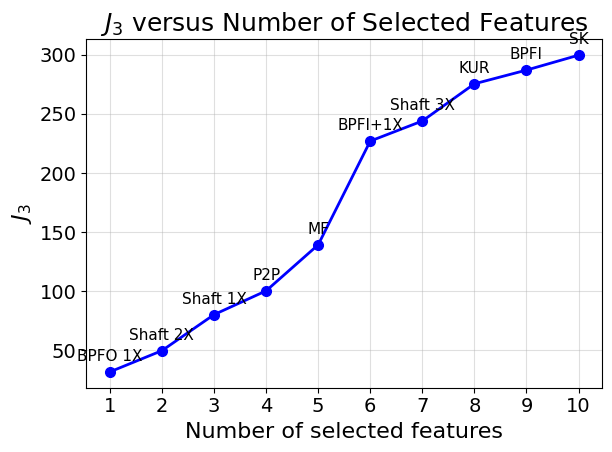

In [ ]:
# Standardize on training data; apply the same scaler to test data
scaler               = StandardScaler()
x_train_standardized = scaler.fit_transform(x_train_raw)
x_test_standardized  = scaler.transform(x_test_raw)

# sequential_forward_j3 is defined in Shared utility functions
selection_path = sequential_forward_j3(
    x_train_standardized, labels_train,
    max_features=n_selected_features, correlation_limit=correlation_limit
)

if len(selection_path) < n_selected_features:
    raise RuntimeError(f"Only {len(selection_path)} features satisfied the correlation limit.")

selected_indices = selection_path[-1][2]
selected_names   = [feature_names[i] for i in selected_indices]

selected_table = pd.DataFrame({
    "Selection order":    np.arange(1, len(selection_path) + 1),
    "Feature":            [feature_names[row[0]] for row in selection_path],
    "J3 after addition":  [row[1]                for row in selection_path]
})
display(selected_table.round({"J3 after addition": 4}))

n_feat      = selected_table["Selection order"]
j3_vals     = selected_table["J3 after addition"]
labels_feat = selected_table["Feature"]

plt.figure()
plt.plot(n_feat, j3_vals, "bo-", linewidth=2, markersize=7)
for x_val, y_val, name in zip(n_feat, j3_vals, labels_feat):
    plt.annotate(name, xy=(x_val, y_val), xytext=(0, 8),
                 textcoords="offset points", ha="center", fontsize=11)
plt.xlabel("Number of selected features");  plt.ylabel("$J_3$")
plt.title("$J_3$ versus Number of Selected Features")
plt.xticks(n_feat);  plt.grid(True, alpha=0.4)
plt.tight_layout();  plt.show()


### Train ANN and apply to test data

10 inputs → 10 ReLU neurons → 7 Softmax outputs. Training set divided 80:20 for training/validation. PyTorch full-batch training is used so the full process is visible in code.

ANN: 10 inputs → 10 ReLU → 7 Softmax
Parameters: 187,  Best epoch: 787
Train accuracy: 1.0000,  Validation: 0.9500
Test accuracy:  0.9524,  Balanced test accuracy: 0.9524


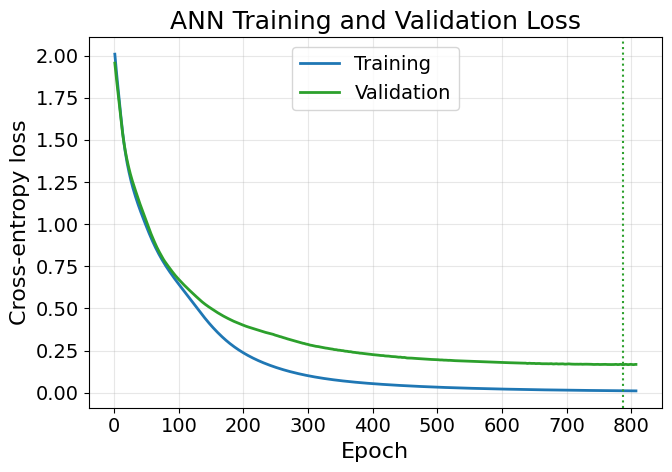

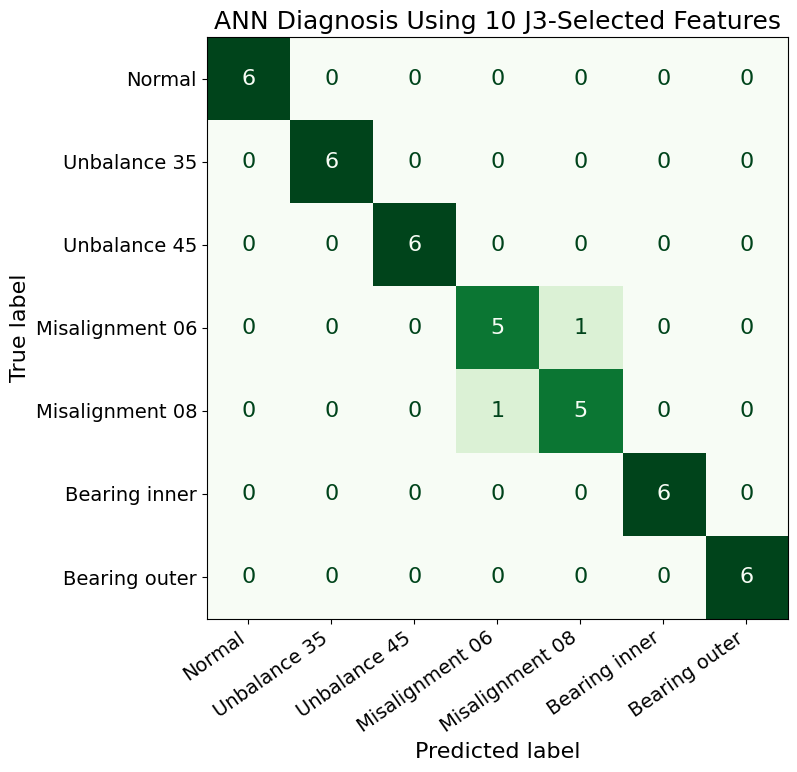

In [ ]:
hidden_neurons = 10;  learning_rate = 0.01
maximum_epochs = 1000;  patience = 20

x_selected_train = x_train_standardized[:, selected_indices]
x_selected_test  = x_test_standardized[:,  selected_indices]

ann_train_index, validation_index = train_test_split(
    np.arange(len(labels_train)), test_size=validation_ratio,
    stratify=labels_train, random_state=random_state
)

x_ann_train        = torch.FloatTensor(x_selected_train[ann_train_index])
x_validation       = torch.FloatTensor(x_selected_train[validation_index])
x_ann_test         = torch.FloatTensor(x_selected_test)
labels_ann_train   = torch.LongTensor(labels_train[ann_train_index])
labels_validation  = torch.LongTensor(labels_train[validation_index])

class NetRK4(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden_layer = nn.Linear(n_selected_features, hidden_neurons)
        self.output_layer = nn.Linear(hidden_neurons, 7)
    def forward(self, x):
        return self.output_layer(torch.relu(self.hidden_layer(x)))

torch.manual_seed(random_state)
net_rk4   = NetRK4()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net_rk4.parameters(), lr=learning_rate)

train_losses, validation_losses = [], []
best_validation_loss = float("inf");  best_epoch = 0
best_state = copy.deepcopy(net_rk4.state_dict());  counter = 0

for epoch in range(maximum_epochs):
    net_rk4.train()
    train_loss = criterion(net_rk4(x_ann_train), labels_ann_train)
    optimizer.zero_grad();  train_loss.backward();  optimizer.step()

    net_rk4.eval()
    with torch.no_grad():
        validation_loss = criterion(net_rk4(x_validation), labels_validation)

    train_losses.append(train_loss.item());  validation_losses.append(validation_loss.item())

    if validation_loss.item() < best_validation_loss:
        best_validation_loss = validation_loss.item();  best_epoch = epoch + 1
        best_state = copy.deepcopy(net_rk4.state_dict());  counter = 0
    else:
        counter += 1
    if counter >= patience:
        break

net_rk4.load_state_dict(best_state);  net_rk4.eval()

with torch.no_grad():
    pred_train = torch.argmax(net_rk4(x_ann_train), dim=1).numpy()
    pred_val   = torch.argmax(net_rk4(x_validation), dim=1).numpy()
    pred_test  = torch.argmax(net_rk4(x_ann_test),  dim=1).numpy()

train_acc    = accuracy_score(labels_ann_train.numpy(), pred_train)
val_acc      = accuracy_score(labels_validation.numpy(), pred_val)
test_acc     = accuracy_score(labels_test, pred_test)
test_bal_acc = balanced_accuracy_score(labels_test, pred_test)
cm           = confusion_matrix(labels_test, pred_test, labels=np.arange(7))
total_params = sum(p.numel() for p in net_rk4.parameters())

print(f"ANN: {n_selected_features} inputs → {hidden_neurons} ReLU → 7 Softmax")
print(f"Parameters: {total_params},  Best epoch: {best_epoch}")
print(f"Train accuracy: {train_acc:.4f},  Validation: {val_acc:.4f}")
print(f"Test accuracy:  {test_acc:.4f},  Balanced test accuracy: {test_bal_acc:.4f}")

epochs_arr = np.arange(1, len(train_losses) + 1)
plt.figure(figsize=(7, 5))
plt.plot(epochs_arr, train_losses,      color="tab:blue",  linewidth=2, label="Training")
plt.plot(epochs_arr, validation_losses, color="tab:green", linewidth=2, label="Validation")
plt.axvline(best_epoch, color="tab:green", linestyle=":", linewidth=1.5)
plt.xlabel("Epoch");  plt.ylabel("Cross-entropy loss")
plt.title("ANN Training and Validation Loss")
plt.grid(True, alpha=0.3);  plt.legend()
plt.tight_layout();  plt.show()

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(confusion_matrix=cm,
                       display_labels=list(class_variables.keys())).plot(
    cmap="Greens", values_format="d", ax=ax, colorbar=False
)
ax.set_title("ANN Diagnosis Using 10 J3-Selected Features")
ax.tick_params(axis="x", rotation=35)
for lbl in ax.get_xticklabels(): lbl.set_ha("right")
plt.tight_layout();  plt.show()


## ANN of ZeMA

The ANN has 56 inputs, one hidden layer with 10 neurons, and four Sigmoid outputs. Each output independently indicates whether Cooler, Valve, Pump, or Accumulator is faulty.

All severity levels are merged into fault = 1. A fully healthy cycle gives `[0, 0, 0, 0]`; simultaneous faults are represented directly, e.g. `[1, 1, 0, 1]`.

### Settings

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

data_dir        = DATA_ROOT / "HS_ZeMA"
test_ratio      = 0.30
random_state    = 42
component_names = ["Cooler", "Valve", "Pump", "Accumulator"]
healthy_values  = np.array([100, 100, 0, 130])


### Read profile and create four binary labels

In [ ]:
with h5py.File(data_dir / "profile.mat", "r") as file:
    profile = np.array(file["profile"])

if profile.shape[0] < profile.shape[1]:
    profile = profile.T

n_cycles         = profile.shape[0]
component_states = profile[:, :4].astype(int)

# Convert all severity levels to binary: 0 = healthy, 1 = faulty
labels           = (component_states != healthy_values).astype(int)
number_of_faults = labels.sum(axis=1)
combination_code = np.array(["".join(map(str, row)) for row in labels])
combinations, combination_counts = np.unique(combination_code, return_counts=True)

combination_table = pd.DataFrame({
    "Fault combination": combinations,
    "Number of cycles":  combination_counts
})
print(f"Total cycles: {n_cycles}")
print(f"Binary fault-label matrix: {labels.shape}")
print(f"Observed binary fault combinations: {len(combinations)}")
display(combination_table)


Total cycles: 2205
Binary fault-label matrix: (2205, 4)
Observed binary fault combinations: 16


,Fault combination,Number of cycles
0,0000,21
1,0001,272
2,0010,22
3,0011,66
4,0100,30
5,0101,90
6,0110,60
7,0111,180
8,1000,242
9,1001,326


### Read and resample the 14 sensor signals

In [ ]:
sensors_100hz = ["PS1","PS2","PS3","PS4","PS5","PS6","EPS1"]
sensors_10hz  = ["FS1","FS2"]
sensors_1hz   = ["TS1","TS2","TS3","TS4","VS1"]

sensor_list = ([(name, 100) for name in sensors_100hz] +
               [(name,  10) for name in sensors_10hz]  +
               [(name,   1) for name in sensors_1hz])

# load_sensor_mat and resample_to_5hz are defined in Shared utility functions
channels = [resample_to_5hz(load_sensor_mat(name, data_dir, n_cycles), rate)
            for name, rate in sensor_list]

signals      = np.stack(channels, axis=-1)   # (n_cycles, 300, 14)
sensor_names = [name for name, _ in sensor_list]
print(f"Resampled sensor data: {signals.shape}")


Resampled sensor data: (2205, 300, 14)


### Extract 56 statistical features

In [ ]:
# extract_cycle_features is defined in Shared utility functions
feature_types     = ["Mean", "STD", "Skewness", "Kurtosis"]
feature_names_zema = [
    f"{sensor_name} {ft}"
    for ft in feature_types
    for sensor_name in sensor_names
]

features = extract_cycle_features(signals)
features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)

print(f"Feature matrix: {features.shape}")
print(f"Features per cycle: {len(feature_names_zema)}")


/usr/local/lib/python3.12/dist-packages/scipy/stats/_stats_py.py:1361: RuntimeWarning: invalid value encountered in divide
  nval = ((n - 1.0) * n)**0.5 / (n - 2.0) * m3 / m2**1.5


Feature matrix: (2205, 56)
Features per cycle: 56


/usr/local/lib/python3.12/dist-packages/scipy/stats/_stats_py.py:1469: RuntimeWarning: invalid value encountered in divide
  nval = 1.0/(n-2)/(n-3) * ((n**2-1.0)*m4/m2**2.0 - 3*(n-1)**2.0)


### Stratified 70:30 split

In [ ]:
train_index, test_index = train_test_split(
    np.arange(n_cycles), test_size=test_ratio,
    stratify=combination_code, random_state=random_state
)

x_train_raw      = features[train_index];  x_test_raw      = features[test_index]
labels_train     = labels[train_index];    labels_test     = labels[test_index]
fault_count_test = number_of_faults[test_index]

scaler  = StandardScaler()
x_train = scaler.fit_transform(x_train_raw)
x_test  = scaler.transform(x_test_raw)

print(f"Training data: {x_train.shape},  Test data: {x_test.shape}")


Training data: (1543, 56),  Test data: (662, 56)


### Divide ANN training and validation data

In [ ]:
ann_validation_ratio = 0.20
combination_train    = combination_code[train_index]

ann_train_index, validation_index = train_test_split(
    np.arange(len(train_index)), test_size=ann_validation_ratio,
    stratify=combination_train, random_state=random_state
)

x_ann_train_raw   = x_train_raw[ann_train_index]
x_validation_raw  = x_train_raw[validation_index]
labels_ann_train  = labels_train[ann_train_index]
labels_validation = labels_train[validation_index]

scaler_ann   = StandardScaler()
x_ann_train  = scaler_ann.fit_transform(x_ann_train_raw)
x_validation = scaler_ann.transform(x_validation_raw)
x_ann_test   = scaler_ann.transform(x_test_raw)

print(f"ANN training: {x_ann_train.shape},  Validation: {x_validation.shape},  Test: {x_ann_test.shape}")


ANN training: (1234, 56),  Validation: (309, 56),  Test: (662, 56)


### Train ANN

ANN: 56 inputs → 10 ReLU → 4 Sigmoid
Parameters: 614,  Best epoch: 42
Training accuracy: 0.9939,  Validation: 0.9838
Training exact-combination: 0.9757,  Validation: 0.9353


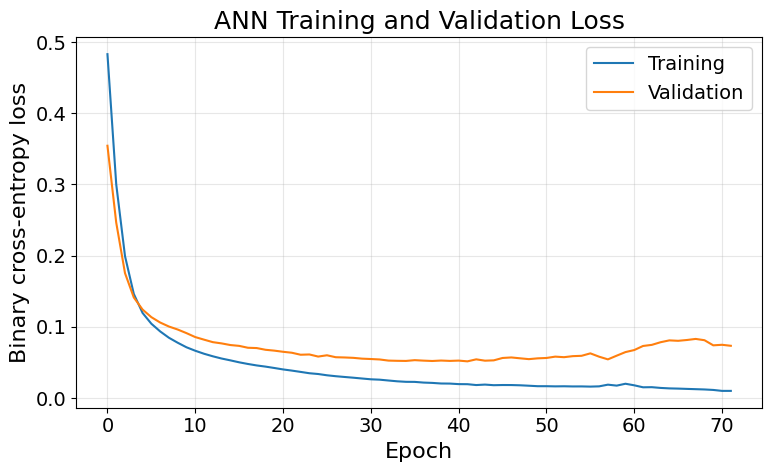

In [ ]:
hidden_neurons = 10;  learning_rate = 0.01
maximum_epochs = 1000;  batch_size = 32;  patience = 30

tf.keras.utils.set_random_seed(random_state)

ann_model = models.Sequential([
    layers.Input(shape=(features.shape[1],)),
    layers.Dense(hidden_neurons, activation="relu"),
    layers.Dense(4, activation="sigmoid")
])
ann_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss="binary_crossentropy", metrics=["binary_accuracy"]
)

history = ann_model.fit(
    x_ann_train, labels_ann_train,
    validation_data=(x_validation, labels_validation),
    epochs=maximum_epochs, batch_size=batch_size,
    callbacks=[EarlyStopping(monitor="val_loss", patience=patience,
                             restore_best_weights=True)],
    verbose=0
)

best_epoch  = np.argmin(history.history["val_loss"]) + 1
train_prob  = ann_model.predict(x_ann_train,  verbose=0)
val_prob    = ann_model.predict(x_validation, verbose=0)
train_pred  = (train_prob >= 0.5).astype(int)
val_pred    = (val_prob   >= 0.5).astype(int)

training_accuracy   = np.mean(labels_ann_train  == train_pred)
validation_accuracy = np.mean(labels_validation == val_pred)
training_exact      = np.mean(np.all(labels_ann_train  == train_pred, axis=1))
validation_exact    = np.mean(np.all(labels_validation == val_pred,   axis=1))

print(f"ANN: {features.shape[1]} inputs → {hidden_neurons} ReLU → 4 Sigmoid")
print(f"Parameters: {ann_model.count_params()},  Best epoch: {best_epoch}")
print(f"Training accuracy: {training_accuracy:.4f},  Validation: {validation_accuracy:.4f}")
print(f"Training exact-combination: {training_exact:.4f},  Validation: {validation_exact:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"],     label="Training")
plt.plot(history.history["val_loss"], label="Validation")
plt.xlabel("Epoch");  plt.ylabel("Binary cross-entropy loss")
plt.title("ANN Training and Validation Loss")
plt.legend();  plt.grid(True, alpha=0.3)
plt.tight_layout();  plt.show()


### Apply ANN to test data

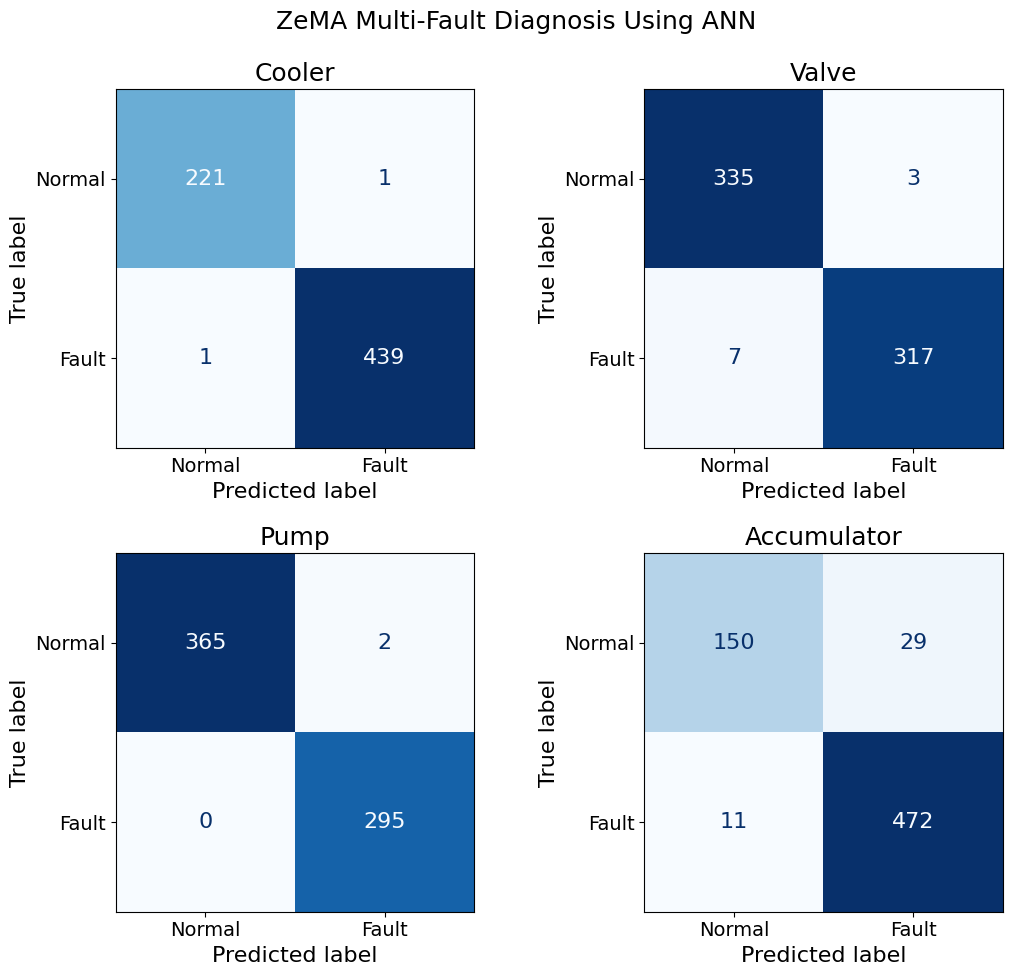

Average label accuracy: 0.9796
Exact combination accuracy: 0.9215


,Component,Accuracy,Balanced accuracy
0,Cooler,0.9970,0.9966
1,Valve,0.9849,0.9848
2,Pump,0.9970,0.9973
3,Accumulator,0.9396,0.9076


,Number of simultaneous faults,Test cycles,Exact-match accuracy
0,0,6,1.0000
1,1,170,0.9000
2,2,194,0.9021
3,3,184,0.9511
4,4,108,0.9352


In [ ]:
# evaluate_multifault is defined in Shared utility functions
fault_probability = ann_model.predict(x_ann_test, verbose=0)
labels_predicted  = (fault_probability >= 0.5).astype(int)

ann_result, ann_label_accuracy, ann_exact_match = evaluate_multifault(
    labels_test, labels_predicted,
    "ZeMA Multi-Fault Diagnosis Using ANN",
    component_names, fault_count_test
)


### Illustration of fault diagnoses

In [ ]:
# Show ground-truth vs. predicted labels for the first 10 test cycles
example_rows = []
for local_index in range(10):
    row = {"Test cycle": int(test_index[local_index])}
    for comp_idx, comp_name in enumerate(component_names):
        row[f"True {comp_name}"]      = int(labels_test[local_index, comp_idx])
        row[f"Predicted {comp_name}"] = int(labels_predicted[local_index, comp_idx])
    example_rows.append(row)
display(pd.DataFrame(example_rows))


,Test cycle,True Cooler,Predicted Cooler,True Valve,Predicted Valve,True Pump,Predicted Pump,True Accumulator,Predicted Accumulator
0,1558,0,0,0,0,0,0,1,1
1,1471,0,0,0,0,0,0,1,1
2,1897,0,0,1,1,0,0,1,0
3,650,1,1,0,0,1,1,1,1
4,1412,1,1,1,1,1,1,1,1
5,1359,1,1,1,1,1,1,1,1
6,1990,0,0,1,1,1,1,1,1
7,1954,0,0,1,1,1,1,1,1
8,779,1,1,0,0,0,0,1,1
9,1090,1,1,1,1,1,1,1,1


# Knowledge based method

## Empirical fault diagnosis of RK4

### Read RK4

In [ ]:
# Load frequency-domain features for all seven conditions using DATA_ROOT
domain_file_kb = DATA_ROOT / "RK4_Rotor_Kit" / "RK4_feat_domain.mat"
data_kb = sio.loadmat(domain_file_kb)

nor    = data_kb["FNor"];    unb35 = data_kb["FUnb35"];  unb45 = data_kb["FUnb45"]
mis06  = data_kb["FMis06"];  mis08 = data_kb["FMis08"]
binner = data_kb["FBin"];    bouter = data_kb["FBout"]


### Classify shaft and bearing fault

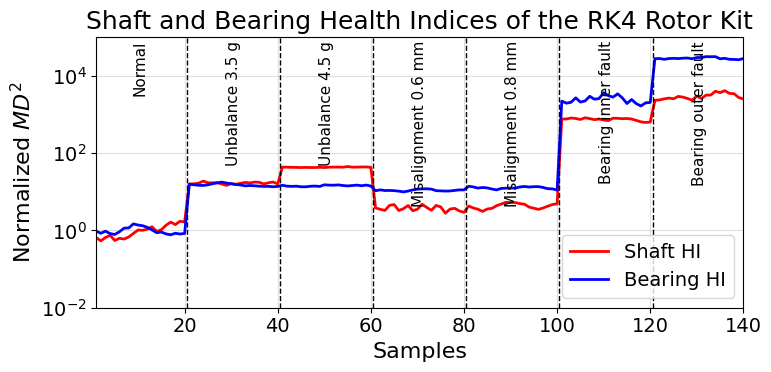

In [ ]:
# Compute normalized Mahalanobis Distance squared using the Normal condition as reference.
# smooth() is defined in Shared utility functions.
Test  = np.vstack((nor, unb35, unb45, mis06, mis08, binner, bouter))
Train = nor;  n_train = Train.shape[0]

def mahalanobis_hi(test_data, train_data, feature_cols):
    # Returns Mahalanobis-based Health Index normalized to the training mean
    mean_t  = np.mean(train_data[:, feature_cols], axis=0)
    cov_t   = np.cov(train_data[:, feature_cols], rowvar=False)
    inv_cov = np.linalg.pinv(cov_t)
    diff    = test_data[:, feature_cols] - mean_t
    md2     = np.einsum("ij,jk,ik->i", diff, inv_cov, diff)
    return md2 / np.mean(md2[:n_train])

HI_shaft   = mahalanobis_hi(Test, Train, list(range(3)))    # shaft: cols 0-2
HI_bearing = mahalanobis_hi(Test, Train, list(range(3, 9))) # bearing: cols 3-8

# Five-sample centered moving average within each condition block
SHI_shaft   = np.concatenate([smooth(HI_shaft[20*i:20*(i+1)])   for i in range(7)])
SHI_bearing = np.concatenate([smooth(HI_bearing[20*i:20*(i+1)]) for i in range(7)])

condition_labels = [
    "Normal", "Unbalance 3.5 g", "Unbalance 4.5 g",
    "Misalignment 0.6 mm", "Misalignment 0.8 mm",
    "Bearing inner fault", "Bearing outer fault"
]

plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, 141), SHI_shaft,   "r", linewidth=2, label="Shaft HI")
plt.plot(np.arange(1, 141), SHI_bearing, "b", linewidth=2, label="Bearing HI")
plt.yscale("log");  plt.xlim(1, 140);  plt.ylim(1e-2, 1e5)
for boundary in np.arange(20.5, 140, 20):
    plt.axvline(boundary, color="black", linestyle="--", linewidth=1)
for center, lbl in zip(np.arange(10.5, 140, 20), condition_labels):
    plt.text(center, 8e4, lbl, rotation=90, ha="center", va="top", fontsize=11)
plt.xlabel("Samples");  plt.ylabel(r"Normalized $MD^2$")
plt.title("Shaft and Bearing Health Indices of the RK4 Rotor Kit")
plt.legend(loc="lower right")
plt.grid(True, which="both", alpha=0.4)
plt.tight_layout();  plt.show()


### Classify shaft fault

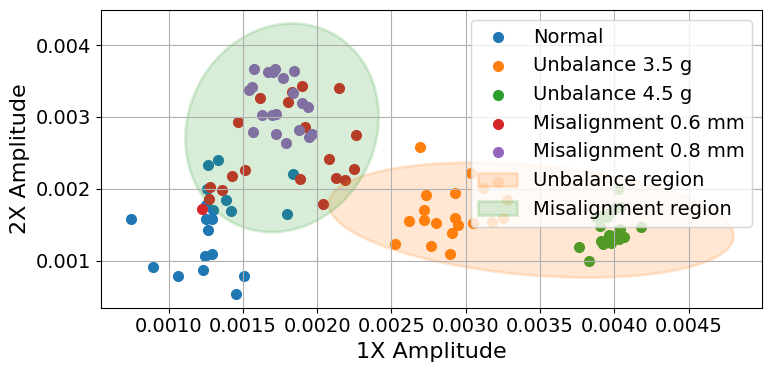

In [ ]:
# Scatter plot of 1X vs 2X amplitude to distinguish unbalance and misalignment.
# add_ellipse is defined in Shared utility functions.
xlines = [0, 20, 40, 60, 80, 100, 120]
shaft_labels = [
    "Normal", "Unbalance 3.5 g", "Unbalance 4.5 g",
    "Misalignment 0.6 mm", "Misalignment 0.8 mm"
]

fig, ax = plt.subplots(figsize=(8, 4))
for k in range(5):
    ax.scatter(Test[xlines[k]:xlines[k+1], 0],
               Test[xlines[k]:xlines[k+1], 1],
               linewidths=2, label=shaft_labels[k])

# Combine both severity levels of each fault type for the ellipses
add_ellipse(ax, Test[xlines[1]:xlines[3], 0:2], color="tab:orange", label="Unbalance region")
add_ellipse(ax, Test[xlines[3]:xlines[5], 0:2], color="tab:green",  label="Misalignment region")

ax.set_xlabel("1X Amplitude");  ax.set_ylabel("2X Amplitude")
ax.grid(True);  ax.legend(loc="best")
plt.tight_layout();  plt.show()
